# Huggingface Token

In [ ]:
HF_TOKEN = ""

# Source Separation (Vocal-Music Separation)

In [ ]:
from audio_separator.separator import Separator

separator = Separator(
    output_dir='separated_audio',
    output_format='WAV'
)

# - Kim_Vocal_2 is one of the best for clean vocal extraction
# - 'model_bs_roformer_ep_317_sdr_12.9755.ckpt' (state-of-the-art, but larger/slower)
# - 'UVR_MDXNET_KARA_2.onnx' (good for karaoke-style separation)
# - 'MDX23C-8KFFT-InstVoc_HQ.ckpt' (high quality, balanced)
separator.load_model('model_bs_roformer_ep_317_sdr_12.9755.ckpt')

output_files = separator.separate('D:\\Personal Projects\\Movie_Dub\\Teri Meri Prem Kahani Bodyguard.mp3')
print(f"Separation complete! Output files: {output_files}")

2026-03-15 16:08:10,091 - INFO - separator - Separator version 0.41.1 instantiating with output_dir: temp/output, output_format: WAV
2026-03-15 16:08:10,091 - INFO - separator - Using model directory from model_file_dir parameter: /tmp/audio-separator-models/
2026-03-15 16:08:10,098 - INFO - separator - Operating System: Windows 10.0.26200
2026-03-15 16:08:10,098 - INFO - separator - System: Windows Node: Jit Release: 10 Machine: AMD64 Proc: AMD64 Family 23 Model 96 Stepping 1, AuthenticAMD
2026-03-15 16:08:10,098 - INFO - separator - Python Version: 3.11.14
2026-03-15 16:08:10,098 - INFO - separator - PyTorch Version: 2.6.0+cu124
2026-03-15 16:08:11,361 - INFO - separator - FFmpeg installed: ffmpeg version 8.0.1-full_build-www.gyan.dev Copyright (c) 2000-2025 the FFmpeg developers
2026-03-15 16:08:11,369 - INFO - separator - ONNX Runtime GPU package installed with version: 1.24.3
2026-03-15 16:08:11,371 - INFO - separator - ONNX Runtime CPU package installed with version: 1.24.3
2026-

Vocal file: temp/vocal\vocal.wav
Music file: temp/music\music.wav


# Simple Speaker Diarization

In [ ]:
# Windows/Jupyter-safe NeMo diarization runner.
# Runs diarization in a standalone script to avoid multiprocessing pickling issues in notebooks.

import os
import subprocess
from pathlib import Path

AUDIO_FILE = r"D:\Personal Projects\Movie_Dub\Audio_Samples\Podcast.wav"
OUTPUT_DIR = Path("./diarization_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

runner_path = OUTPUT_DIR / "run_nemo_diarization.py"

runner_code = r'''
import os
import json
import wget
from pathlib import Path
from omegaconf import OmegaConf
from nemo.collections.asr.models import ClusteringDiarizer


def main():
    audio_file = r"D:\Personal Projects\Movie_Dub\Audio_Samples\Podcast.wav"
    output_dir = Path("./diarization_output")
    output_dir.mkdir(parents=True, exist_ok=True)

    manifest_path = output_dir / "input_manifest.json"

    manifest_entry = {
        "audio_filepath": audio_file,
        "offset": 0,
        "duration": None,
        "label": "infer",
        "text": "-",
        "num_speakers": None,
        "rttm_filepath": None,
        "uem_filepath": None,
    }

    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest_entry, f)
        f.write("\n")

    config_url = (
        "https://raw.githubusercontent.com/NVIDIA/NeMo/main/examples/"
        "speaker_tasks/diarization/conf/inference/diar_infer_general.yaml"
    )
    config_path = output_dir / "diar_infer_general.yaml"

    if not config_path.exists():
        print("Downloading config...")
        wget.download(config_url, str(config_path))
        print(f"\nConfig downloaded to: {config_path}")

    cfg = OmegaConf.load(str(config_path))

    # Core diarizer config
    cfg.diarizer.manifest_filepath = str(manifest_path)
    cfg.diarizer.out_dir = str(output_dir)
    cfg.diarizer.oracle_vad = False
    cfg.diarizer.collar = 0.25
    cfg.diarizer.ignore_overlap = True

    # Force single-process dataloading on Windows
    cfg.num_workers = 0
    cfg.batch_size = 1
    cfg.diarizer.num_workers = 0

    # VAD config
    cfg.diarizer.vad.model_path = "vad_multilingual_marblenet"
    cfg.diarizer.vad.parameters.onset = 0.8
    cfg.diarizer.vad.parameters.offset = 0.6
    cfg.diarizer.vad.parameters.min_duration_on = 0.1
    cfg.diarizer.vad.parameters.min_duration_off = 0.4

    # Speaker embeddings config
    cfg.diarizer.speaker_embeddings.model_path = "titanet_large"
    cfg.diarizer.speaker_embeddings.parameters.window_length_in_sec = 1.5
    cfg.diarizer.speaker_embeddings.parameters.shift_length_in_sec = 0.75
    cfg.diarizer.speaker_embeddings.parameters.multiscale_weights = None

    # Clustering config
    cfg.diarizer.clustering.parameters.oracle_num_speakers = False
    cfg.diarizer.clustering.parameters.max_num_speakers = 10

    print("\n" + "=" * 60)
    print("Running NeMo ClusteringDiarizer...")
    print("=" * 60)

    diarizer = ClusteringDiarizer(cfg=cfg)
    diarizer.diarize()

    audio_basename = Path(audio_file).stem
    rttm_path = output_dir / "pred_rttms" / f"{audio_basename}.rttm"

    print("\n" + "=" * 60)
    print("DIARIZATION RESULTS (RTTM Format)")
    print("=" * 60)

    if rttm_path.exists():
        print(f"\nRTTM file: {rttm_path}\n")
        print(f"{'Speaker':^15} | {'Start (s)':^12} | {'End (s)':^12} | {'Duration (s)':^12}")
        print("-" * 60)
        with open(rttm_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                start = float(parts[3])
                duration = float(parts[4])
                end = start + duration
                speaker = parts[7]
                print(f"{speaker:^15} | {start:>12.2f} | {end:>12.2f} | {duration:>12.2f}")
    else:
        print(f"RTTM file not found at: {rttm_path}")


if __name__ == "__main__":
    main()
'''

runner_path.write_text(runner_code, encoding="utf-8")
print(f"Created runner script: {runner_path}")

# Use the same Python executable as the notebook kernel when possible.
python_exe = os.environ.get("PYTHON_EXECUTABLE", "python")
cmd = [python_exe, str(runner_path)]
print("Running:", " ".join(cmd))

proc = subprocess.run(cmd, text=True, capture_output=True)
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(f"Diarization script failed with exit code {proc.returncode}")


# Overlapping Speech Timestamp Detection

✓ torch.load patched (once)


d:\Personal Projects\Movie_Dub\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[NeMo W 2026-03-15 11:22:19 megatron_init:62] Megatron num_microbatches_calculator not found, using Apex version.
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.
[NeMo W 2026-03-15 11:22:22 nemo_logging:364] d:\Personal Projects\Movie_Dub\venv\Lib\site-packages\pyannote\audio\utils\reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
    It can be re-enabled by calling
       >>> import torch
       >>> torch.backen

✓ Model and pipeline loaded successfully
Running on: cuda

Processing: D:\Personal Projects\Movie_Dub\mixture.wav ...

  Detected 2 overlapping speech region(s)
  [  1]  1.010s  →  1.752s    (0.742s)
  [  2]  2.292s  →  3.912s    (1.620s)
  Total overlap : 2.362s

As list: [(1.01, 1.752), (2.292, 3.912)]


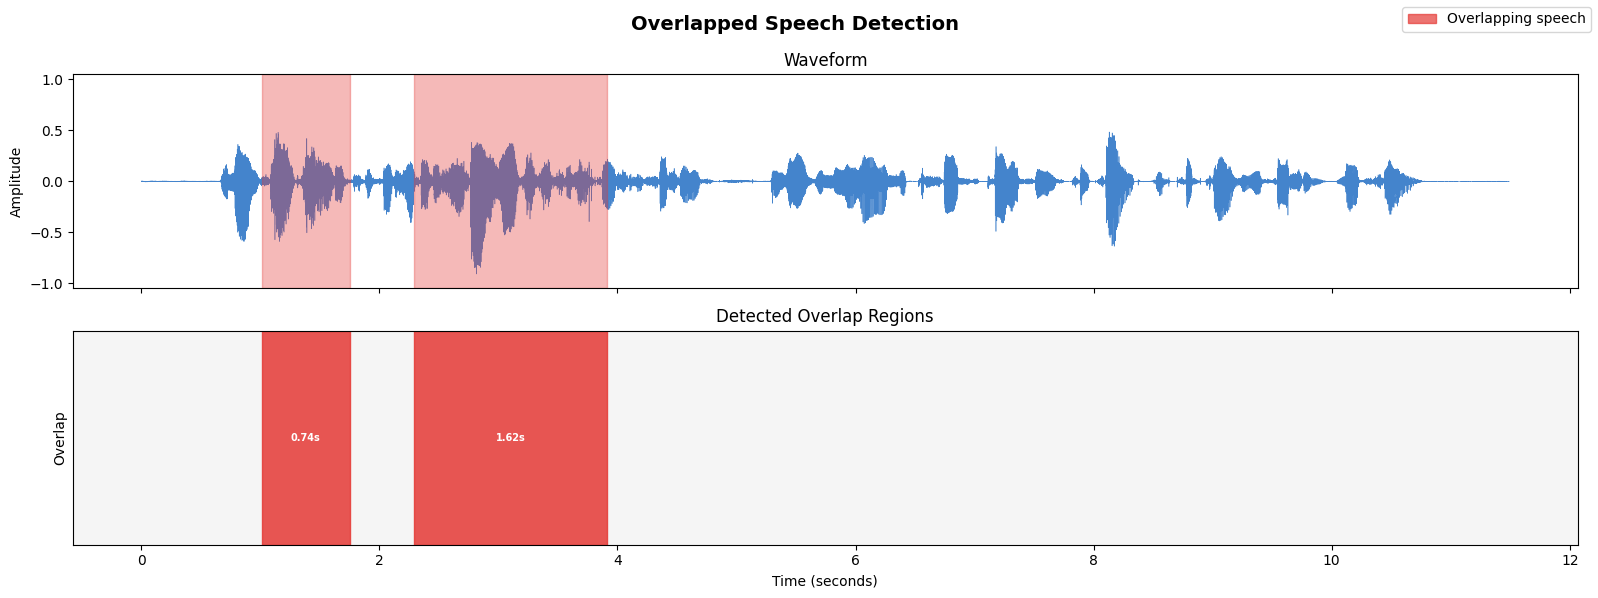

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Run ONCE after kernel restart. Do NOT re-run.
# ══════════════════════════════════════════════════════════════
import torch
import torch.serialization
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.torch_version import TorchVersion

# ── Grab the TRUE original before any patching ────────────────
_TRUE_TORCH_LOAD = torch.load.__wrapped__ if hasattr(torch.load, '__wrapped__') else torch.load

# ── Patch exactly once using a guard flag ─────────────────────
if not getattr(torch.load, '_pyannote_patched', False):
    
    def _patched_torch_load(f, map_location=None, pickle_module=None,
                             weights_only=True, mmap=None, **kwargs):
        return _TRUE_TORCH_LOAD(
            f,
            map_location=map_location,
            pickle_module=pickle_module,
            weights_only=False,
            **kwargs
        )
    
    _patched_torch_load._pyannote_patched = True   # guard flag
    torch.load = _patched_torch_load
    print("✓ torch.load patched (once)")
else:
    print("⚠ Patch already applied — skipping")

# ── Allowlist pyannote globals ────────────────────────────────
from pyannote.audio.core.task import Specifications
from pyannote.core import SlidingWindow
torch.serialization.add_safe_globals([TorchVersion, Specifications, SlidingWindow])

# ── Load model ────────────────────────────────────────────────
from pyannote.audio import Model, Audio
from pyannote.audio.pipelines import OverlappedSpeechDetection

HF_TOKEN = ""

model = Model.from_pretrained("pyannote/segmentation-3.0", use_auth_token=HF_TOKEN)
pipeline = OverlappedSpeechDetection(segmentation=model)
print("✓ Model and pipeline loaded successfully")


# ══════════════════════════════════════════════════════════════
# CELL 2 — Inference + Visualization (safe to re-run freely)
# ══════════════════════════════════════════════════════════════
AUDIO_FILE = "D:\\Personal Projects\\Movie_Dub\\mixture.wav"

HYPER_PARAMETERS = {
    "min_duration_on":  0.1,
    "min_duration_off": 0.1,
}

pipeline.instantiate(HYPER_PARAMETERS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pipeline.to(device)
print(f"Running on: {device}")

print(f"\nProcessing: {AUDIO_FILE} ...")
osd_output = pipeline(AUDIO_FILE)

overlap_segments = [
    (round(seg.start, 3), round(seg.end, 3))
    for seg in osd_output.get_timeline().support()
]

# ── Print ──────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Detected {len(overlap_segments)} overlapping speech region(s)")
print(f"{'='*50}")
total_overlap = 0.0
for i, (s, e) in enumerate(overlap_segments):
    dur = e - s
    total_overlap += dur
    print(f"  [{i+1:>3}]  {s:.3f}s  →  {e:.3f}s    ({dur:.3f}s)")
print(f"{'='*50}")
print(f"  Total overlap : {total_overlap:.3f}s")
print(f"\nAs list: {overlap_segments}")

# ── Plot ───────────────────────────────────────────────────────
def plot_osd(audio_path, segments):
    io = Audio(sample_rate=16000, mono=True)
    waveform, sr = io({"audio": audio_path, "channel": 0})
    waveform = waveform.squeeze().numpy()
    duration = len(waveform) / sr
    time_axis = np.linspace(0, duration, len(waveform))

    fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
    fig.suptitle("Overlapped Speech Detection", fontsize=14, fontweight="bold")

    axes[0].plot(time_axis, waveform, color="#1565C0", linewidth=0.4, alpha=0.8)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Waveform")
    axes[0].set_ylim(-1.05, 1.05)
    for s, e in segments:
        axes[0].axvspan(s, e, alpha=0.35, color="#E53935", zorder=2)

    axes[1].set_ylabel("Overlap")
    axes[1].set_title("Detected Overlap Regions")
    axes[1].set_ylim(0, 1)
    axes[1].set_yticks([])
    axes[1].set_facecolor("#F5F5F5")
    for s, e in segments:
        axes[1].axvspan(s, e, alpha=0.85, color="#E53935", zorder=2)
        if (e - s) > 0.3:
            axes[1].text((s+e)/2, 0.5, f"{e-s:.2f}s",
                         ha="center", va="center",
                         fontsize=7, color="white", fontweight="bold")

    axes[1].set_xlabel("Time (seconds)")
    overlap_patch = mpatches.Patch(color="#E53935", alpha=0.7, label="Overlapping speech")
    fig.legend(handles=[overlap_patch], loc="upper right", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_osd(AUDIO_FILE, overlap_segments)

# Simple Speech Separation

In [ ]:
import os
import soundfile as sf
from espnet_model_zoo.downloader import ModelDownloader
from espnet2.bin.enh_inference import SeparateSpeech

fs = 8000

tag = "lichenda/wsj0_2mix_skim_noncausal"
# Other options:
# "espnet/chenda-li-wsj0_2mix_enh_train_enh_conv_tasnet_raw_valid.si_snr.ave"
# "espnet/chenda-li-wsj0_2mix_enh_train_enh_rnn_tf_raw_valid.si_snr.ave"
# "lichenda/Chenda_Li_wsj0_2mix_enh_dprnn_tasnet"
# "espnet/Wangyou_Zhang_wsj0_2mix_enh_dc_crn_mapping_snr_raw"


d = ModelDownloader()
cfg = d.download_and_unpack(tag)
separate_speech = SeparateSpeech(
    train_config=cfg["train_config"],
    model_file=cfg["model_file"],
    segment_size=2.4,
    hop_size=0.8,
    normalize_segment_scale=False,
    show_progressbar=True,
    ref_channel=None,
    normalize_output_wav=True,
    device="cuda"   
)

mixwav, sr = sf.read(r"D:\Personal Projects\Movie_Dub\mixture.wav")
waves = separate_speech(mixwav[None, ...], fs=sr)
sf.write("speaker1.wav", waves[0].squeeze(), sr)
sf.write("speaker2.wav", waves[1].squeeze(), sr)

# Speaker Identification

In [ ]:
# Install if needed
# !pip install speechbrain torchaudio

import torch
import torchaudio
import torch.nn.functional as F
from pathlib import Path
from speechbrain.pretrained import EncoderClassifier

# -----------------------------
# Settings
# -----------------------------

SPEAKER_DB_DIR = "./speakers"     # folder containing speaker subfolders
QUERY_AUDIO    = "query.wav"      # audio to identify
THRESHOLD      = 0.70
CHUNK_SEC      = 3.0

# -----------------------------
# Load ECAPA-TDNN model
# -----------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

classifier = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="pretrained_models/spkrec-ecapa-voxceleb",
    run_opts={"device": device},
)

# -----------------------------
# Audio utilities
# -----------------------------

def load_audio(path, target_sr=16000):
    signal, sr = torchaudio.load(path)
    
    if signal.shape[0] > 1:
        signal = signal.mean(dim=0, keepdim=True)
        
    if sr != target_sr:
        signal = torchaudio.functional.resample(signal, sr, target_sr)
        
    return signal


def chunk_signal(signal, sr=16000, chunk_sec=CHUNK_SEC):
    chunk_len = int(sr * chunk_sec)
    chunks = [signal[:, i:i+chunk_len] for i in range(0, signal.shape[-1], chunk_len)]
    chunks = [c for c in chunks if c.shape[-1] >= sr * 0.5]
    
    return chunks if chunks else [signal]


# -----------------------------
# Embedding functions
# -----------------------------

@torch.no_grad()
def embed_signal(signal):
    emb = classifier.encode_batch(signal)
    emb = emb.squeeze()
    return F.normalize(emb, dim=0)


def embed_long_audio(path):
    signal = load_audio(path)
    chunks = chunk_signal(signal)

    embeddings = [embed_signal(c) for c in chunks]
    mean_emb = torch.stack(embeddings).mean(dim=0)

    return F.normalize(mean_emb, dim=0)


# -----------------------------
# Build speaker database
# -----------------------------

speaker_db = {}

db_path = Path(SPEAKER_DB_DIR)

for speaker_dir in db_path.iterdir():
    
    if not speaker_dir.is_dir():
        continue
        
    audio_files = list(speaker_dir.glob("*.wav"))
    
    print(f"Embedding speaker: {speaker_dir.name}")
    
    embs = [embed_long_audio(f) for f in audio_files]
    
    mean_emb = torch.stack(embs).mean(dim=0)
    
    speaker_db[speaker_dir.name] = F.normalize(mean_emb, dim=0)

print("\nDatabase speakers:", list(speaker_db.keys()))

# -----------------------------
# Identify query speaker
# -----------------------------

query_emb = embed_long_audio(QUERY_AUDIO)

scores = {}

for speaker, emb in speaker_db.items():
    
    sim = F.cosine_similarity(
        query_emb.unsqueeze(0),
        emb.unsqueeze(0)
    ).item()
    
    scores[speaker] = sim

scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)

best_speaker, best_score = scores[0]

print("\nResults")
print("-------")

for i,(spk,score) in enumerate(scores[:5],1):
    print(f"{i}. {spk:15s}  {score:.4f}")

if best_score >= THRESHOLD:
    print(f"\nMATCH: {best_speaker}  (score {best_score:.4f})")
else:
    print(f"\nUNKNOWN speaker  (best score {best_score:.4f})")

# ASR With Timestamps

In [ ]:
import os
import logging
import warnings
from pathlib import Path
import gc
import tempfile

# Silence NeMo / Lightning / HF informational logs
os.environ["NEMO_LOG_LEVEL"] = "ERROR"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("nemo").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

import nemo.collections.asr as nemo_asr
from nemo.utils import logging as nemo_logging
import soundfile as sf
import torch

nemo_logging.set_verbosity(nemo_logging.ERROR)

# Use an audio file that exists in your workspace
audio_path = Path(r"D:\Personal Projects\Movie_Dub\Audio_Samples\Podcast.mp3")

if not audio_path.exists():
    raise FileNotFoundError(
        f"Audio file not found: {audio_path}\n"
        "Update 'audio_path' to a valid file before running transcription."
    )

# NeMo Parakeet expects mono audio shaped as (batch, time).
audio, sr = sf.read(str(audio_path), always_2d=True)
mono_audio = audio.mean(axis=1)

tmp_wav = Path(tempfile.gettempdir()) / "podcast_mono_16k.wav"
sf.write(str(tmp_wav), mono_audio, sr)

# Clear GPU cache and unload previously loaded large models from notebook globals.
for var_name in ("model", "asr_model"):
    if var_name in globals():
        del globals()[var_name]
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

asr_model = nemo_asr.models.ASRModel.from_pretrained(
    model_name="nvidia/parakeet-tdt-0.6b-v2",
    map_location=device,
)

try:
    output = asr_model.transcribe(
        [str(tmp_wav)], timestamps=True, batch_size=1, verbose=False
    )
except RuntimeError as e:
    if "out of memory" in str(e).lower() and torch.cuda.is_available():
        del asr_model
        gc.collect()
        torch.cuda.empty_cache()
        asr_model = nemo_asr.models.ASRModel.from_pretrained(
            model_name="nvidia/parakeet-tdt-0.6b-v2",
            map_location=torch.device("cpu"),
        )
        output = asr_model.transcribe(
            [str(tmp_wav)], timestamps=True, batch_size=1, verbose=False
        )
    else:
        raise

word_timestamps = output[0].timestamp["word"]
segment_timestamps = output[0].timestamp["segment"]
char_timestamps = output[0].timestamp["char"]

for stamp in word_timestamps:
    print(f"{stamp['start']}s - {stamp['end']}s : {stamp['word']}")

# Language Detection Of a Timestamp

Loading Whisper small model ...
✓ Whisper small loaded  |  device: cuda
Loading: D:\Personal Projects\Movie_Dub\Audio_Samples\Podcast.wav
Analysis window: 0.00s → 367.37s  (367.4s total)
Target languages: Hindi, English, Bengali

[1/3] Coarse scan  (chunk=5.0s) ...
  [  0.000s →   5.000s]  English     (99.5%)
  [  5.000s →  10.000s]  English     (98.2%)
  [ 10.000s →  15.000s]  English     (98.9%)
  [ 15.000s →  20.000s]  English     (99.7%)
  [ 20.000s →  25.000s]  English     (92.0%)
  [ 25.000s →  30.000s]  English     (95.8%)
  [ 30.000s →  35.000s]  English     (92.9%)
  [ 35.000s →  40.000s]  English     (99.5%)
  [ 40.000s →  45.000s]  English     (100.0%)
  [ 45.000s →  50.000s]  English     (100.0%)
  [ 50.000s →  55.000s]  English     (100.0%)
  [ 55.000s →  60.000s]  English     (100.0%)
  [ 60.000s →  65.000s]  English     (100.0%)
  [ 65.000s →  70.000s]  English     (100.0%)
  [ 70.000s →  75.000s]  English     (100.0%)
  [ 75.000s →  80.000s]  English     (100.0%)
  [ 80

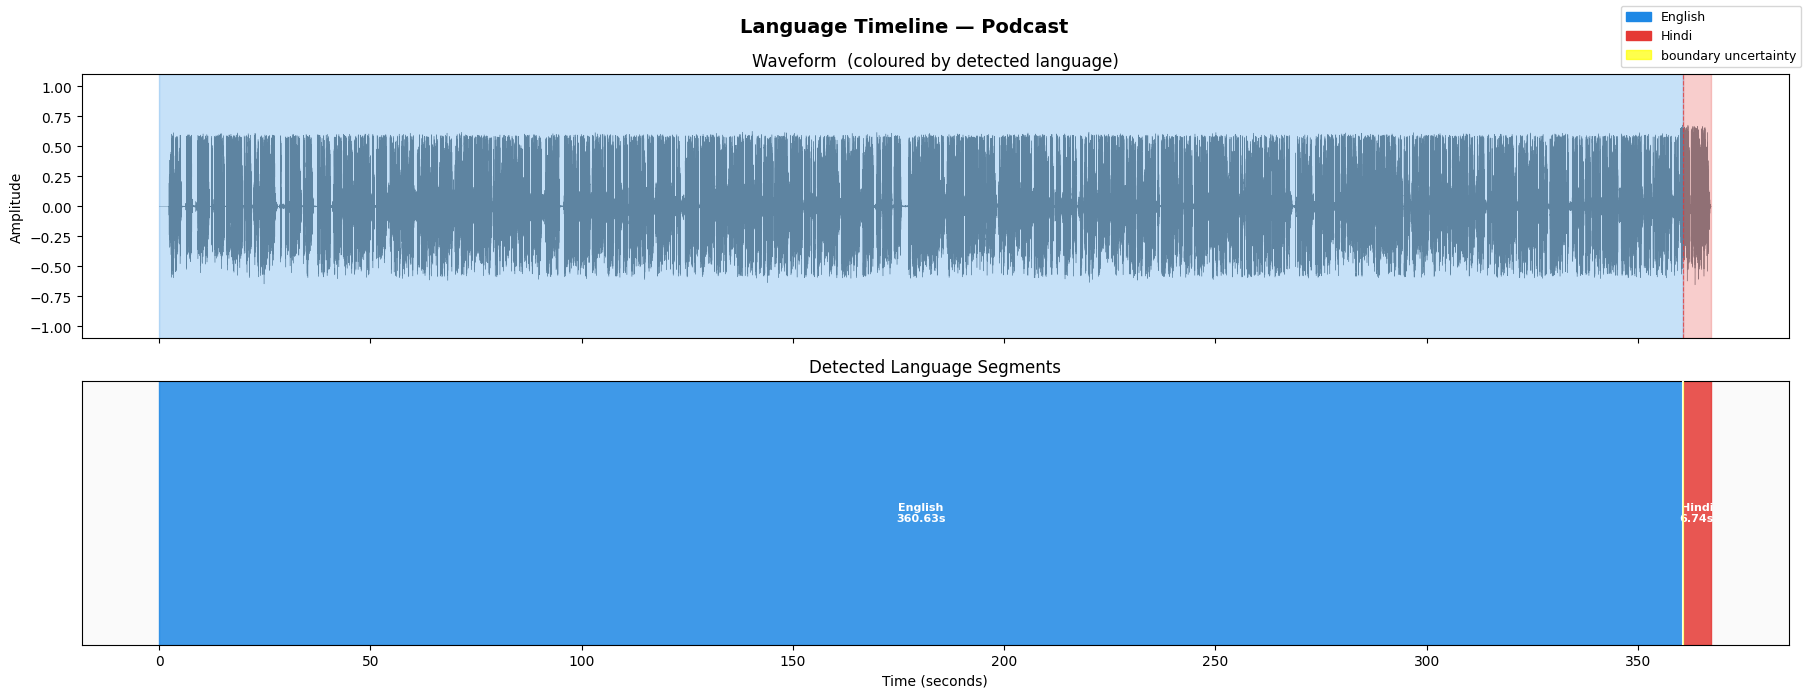

In [6]:
# ══════════════════════════════════════════════════════════════
# LANGUAGE TIMELINE DETECTION — Complete Notebook
# Detects precise timestamps of language switches in audio
# Uses: Whisper-small + Binary Search boundary refinement
# Supports: Hindi, English, Bengali (and 96 other languages)
# ══════════════════════════════════════════════════════════════
# pip install openai-whisper torchaudio torch numpy matplotlib


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — Imports & Model Load (run ONCE)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import whisper
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass
from typing import List, Tuple, Optional

# ── Language display names ────────────────────────────────────
LANG_NAMES = {
    "hi": "Hindi",
    "en": "English",
    "bn": "Bengali",
    "ur": "Urdu",
}

# Colour palette for timeline plot (one per language)
LANG_COLORS = {
    "hi": "#E53935",   # red    → Hindi
    "en": "#1E88E5",   # blue   → English
    "bn": "#43A047",   # green  → Bengali
    "ur": "#FB8C00",   # orange → Urdu
}
DEFAULT_COLOR = "#8E24AA"  # purple → any other language

# ── Load Whisper small (good balance of speed & accuracy) ─────
print("Loading Whisper small model ...")
WHISPER_MODEL = whisper.load_model("small")   # ~460MB, ~32x realtime on CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WHISPER_MODEL = WHISPER_MODEL.to(device)
print(f"✓ Whisper small loaded  |  device: {device}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — Core Helper Functions
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def load_audio_mono16k(wav_path: str) -> Tuple[np.ndarray, float]:
    """
    Load any audio file → 16kHz mono numpy array.
    Returns (waveform_np, total_duration_seconds).
    """
    waveform, sr = torchaudio.load(wav_path)
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    waveform_np = waveform.squeeze().numpy()
    duration = len(waveform_np) / 16000
    return waveform_np, duration


def detect_lang_numpy(
    audio_np     : np.ndarray,
    model        : whisper.Whisper,
    target_langs : Optional[List[str]] = None,
    min_pad_sec  : float = 1.5,
) -> Tuple[str, float]:
    """
    Run Whisper language detection on a raw 16kHz mono numpy array.
    Returns (language_code, confidence).

    Args:
        audio_np     : 16kHz mono audio as numpy float32
        model        : Pre-loaded Whisper model
        target_langs : If given, renormalize probabilities over only these langs
        min_pad_sec  : Pad with silence if audio shorter than this
    """
    sr = 16000
    min_samples = int(min_pad_sec * sr)

    if len(audio_np) < min_samples:
        audio_np = np.pad(audio_np, (0, min_samples - len(audio_np)))

    audio_30s = whisper.pad_or_trim(audio_np.astype(np.float32))
    mel = whisper.log_mel_spectrogram(
        audio_30s,
        n_mels=model.dims.n_mels
    ).to(next(model.parameters()).device)

    with torch.no_grad():
        _, probs = model.detect_language(mel)

    # Renormalize over target languages only
    if target_langs:
        filtered = {k: v for k, v in probs.items() if k in target_langs}
        if filtered:
            total = sum(filtered.values())
            probs = {k: v / total for k, v in filtered.items()}

    best_lang = max(probs, key=probs.get)
    return best_lang, float(probs[best_lang])


def get_slice(waveform: np.ndarray, start_sec: float, end_sec: float) -> np.ndarray:
    """Slice a 16kHz waveform by timestamps."""
    sr = 16000
    return waveform[int(start_sec * sr) : int(end_sec * sr)]


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — Data Classes
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

@dataclass
class CoarseSegment:
    start      : float
    end        : float
    language   : str
    confidence : float

    def __str__(self):
        name = LANG_NAMES.get(self.language, self.language.upper())
        return (f"  [{self.start:7.3f}s → {self.end:7.3f}s]  "
                f"{name:<10}  ({self.confidence:.1%})")


@dataclass
class PreciseLanguageSegment:
    start         : float
    end           : float
    language      : str
    language_name : str
    confidence    : float
    precision_ms  : float   # estimated ±precision of boundaries

    def __str__(self):
        return (
            f"  [{self.start:7.3f}s → {self.end:7.3f}s]  "
            f"{self.language_name:<10}  "
            f"conf={self.confidence:.1%}  "
            f"boundary=±{self.precision_ms:.0f}ms"
        )


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — Step 1: Coarse Language Scan
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def coarse_language_scan(
    waveform      : np.ndarray,
    total_duration: float,
    model         : whisper.Whisper,
    chunk_sec     : float = 5.0,
    target_langs  : Optional[List[str]] = None,
    verbose       : bool = True,
) -> List[CoarseSegment]:
    """
    Slide a fixed window over the audio and detect language per chunk.
    Returns list of CoarseSegment — one per chunk.
    """
    segments = []
    start = 0.0

    if verbose:
        print(f"\n[1/3] Coarse scan  (chunk={chunk_sec}s) ...")

    while start < total_duration:
        end = min(start + chunk_sec, total_duration)
        if (end - start) < 1.0:
            break

        chunk = get_slice(waveform, start, end)
        lang, conf = detect_lang_numpy(chunk, model, target_langs)

        seg = CoarseSegment(
            start=round(start, 3),
            end=round(end, 3),
            language=lang,
            confidence=conf,
        )
        segments.append(seg)

        if verbose:
            print(seg)

        start += chunk_sec

    return segments


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — Step 2: Find Boundary Zones
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def find_boundary_zones(
    coarse_segments : List[CoarseSegment],
    zone_margin     : float = 0.3,  # fraction of chunk to extend zone into each side
) -> List[Tuple[float, float, str, str]]:
    """
    Find adjacent chunk pairs where language changes.
    Returns list of (zone_start, zone_end, lang_before, lang_after).

    The zone is deliberately wider than the exact boundary so binary
    search has headroom on both sides.
    """
    boundaries = []

    for i in range(len(coarse_segments) - 1):
        a = coarse_segments[i]
        b = coarse_segments[i + 1]

        if a.language != b.language:
            chunk_width_a = a.end - a.start
            chunk_width_b = b.end - b.start

            # Extend zone into each neighbouring chunk
            zone_start = a.start + chunk_width_a * (1 - zone_margin)
            zone_end   = b.start + chunk_width_b * zone_margin

            # Safety clamp
            zone_start = max(0.0, zone_start)

            boundaries.append((
                round(zone_start, 3),
                round(zone_end,   3),
                a.language,
                b.language,
            ))

    return boundaries


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — Step 3: Binary Search Refinement
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def binary_search_switch_point(
    waveform       : np.ndarray,
    zone_start     : float,
    zone_end       : float,
    lang_before    : str,
    lang_after     : str,
    model          : whisper.Whisper,
    target_langs   : Optional[List[str]] = None,
    probe_duration : float = 1.5,   # seconds of audio per probe
    max_iterations : int   = 7,     # precision = zone_width / 2^N
    min_zone_width : float = 0.08,  # stop early at ~80ms
    verbose        : bool  = True,
) -> Tuple[float, float, float]:
    """
    Binary search [zone_start, zone_end] to find the exact timestamp
    where speech switches from lang_before → lang_after.

    At each step:
      - Probe the midpoint of the current search window
      - If probe == lang_before → switch is to the RIGHT, move low up
      - If probe == lang_after  → switch is to the LEFT, move high down
      - Repeat until zone < min_zone_width or max_iterations exhausted

    Returns:
        (switch_time, confidence, final_precision_ms)
    """
    low  = zone_start
    high = zone_end
    last_conf = 0.0

    if verbose:
        zone_ms   = (zone_end - zone_start) * 1000
        target_ms = zone_ms / (2 ** max_iterations)
        lb = LANG_NAMES.get(lang_before, lang_before.upper())
        la = LANG_NAMES.get(lang_after,  lang_after.upper())
        print(f"\n  Zone [{zone_start:.3f}s → {zone_end:.3f}s]  "
              f"{lb} → {la}  |  "
              f"width={zone_ms:.0f}ms  target=±{target_ms:.0f}ms")

    for iteration in range(max_iterations):
        if (high - low) < min_zone_width:
            if verbose:
                print(f"    iter {iteration+1}: zone={((high-low)*1000):.0f}ms < "
                      f"{min_zone_width*1000:.0f}ms → stopping early")
            break

        mid = (low + high) / 2.0

        # Centre the probe window on mid
        probe_start = max(zone_start, mid - probe_duration / 2)
        probe_end   = min(zone_end,   mid + probe_duration / 2)

        if (probe_end - probe_start) < 0.5:
            break

        chunk = get_slice(waveform, probe_start, probe_end)
        detected, conf = detect_lang_numpy(chunk, model, target_langs)
        last_conf = conf

        if detected == lang_before:
            low = mid   # switch is to the RIGHT of mid
            direction = "→ right"
        else:
            high = mid  # switch is to the LEFT of mid
            direction = "← left"

        if verbose:
            name = LANG_NAMES.get(detected, detected.upper())
            print(f"    iter {iteration+1}: probe={mid:.3f}s  "
                  f"detected={name}  conf={conf:.1%}  {direction}  "
                  f"zone=[{low:.3f}s,{high:.3f}s]")

    switch_time     = round((low + high) / 2.0, 3)
    precision_ms    = ((high - low) / 2.0) * 1000

    if verbose:
        print(f"  → Switch point: {switch_time:.3f}s  ±{precision_ms:.0f}ms")

    return switch_time, last_conf, precision_ms


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — Step 4: Build Final Timeline
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def build_timeline(
    coarse_segments    : List[CoarseSegment],
    precise_boundaries : List[Tuple[float, float, str, str, float]],
    # each entry: (switch_time, lang_before, lang_after, conf, precision_ms)
    start_sec          : float,
    end_sec            : float,
) -> List[PreciseLanguageSegment]:
    """
    Merge coarse language labels with precisely located switch points
    into a clean final timeline.
    """
    if not precise_boundaries:
        # No switches found → entire segment is one language
        lang = coarse_segments[0].language if coarse_segments else "unknown"
        conf = coarse_segments[0].confidence if coarse_segments else 0.0
        return [PreciseLanguageSegment(
            start         = round(start_sec, 3),
            end           = round(end_sec,   3),
            language      = lang,
            language_name = LANG_NAMES.get(lang, lang.upper()),
            confidence    = conf,
            precision_ms  = 0.0,
        )]

    timeline  = []
    seg_start = start_sec
    seg_lang  = coarse_segments[0].language

    for (sw_time, lang_before, lang_after, conf, prec_ms) in precise_boundaries:
        timeline.append(PreciseLanguageSegment(
            start         = round(seg_start, 3),
            end           = round(sw_time,   3),
            language      = lang_before,
            language_name = LANG_NAMES.get(lang_before, lang_before.upper()),
            confidence    = conf,
            precision_ms  = prec_ms,
        ))
        seg_start = sw_time
        seg_lang  = lang_after

    # Final segment
    last_conf = precise_boundaries[-1][3]
    last_prec = precise_boundaries[-1][4]
    timeline.append(PreciseLanguageSegment(
        start         = round(seg_start, 3),
        end           = round(end_sec,   3),
        language      = seg_lang,
        language_name = LANG_NAMES.get(seg_lang, seg_lang.upper()),
        confidence    = last_conf,
        precision_ms  = last_prec,
    ))

    return timeline


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — Master Function (combines all steps)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def detect_language_timeline(
    wav_path        : str,
    start_sec       : float = 0.0,
    end_sec         : float = None,      # None = full file
    model           : whisper.Whisper = None,
    target_langs    : List[str] = None,  # e.g. ["hi","en","bn"]
    coarse_chunk    : float = 5.0,       # coarse scan window (seconds)
    probe_duration  : float = 1.5,       # binary search probe size (seconds)
    max_iterations  : int   = 7,         # precision = zone_width / 2^N
    min_zone_width  : float = 0.08,      # stop binary search below ~80ms
    verbose         : bool  = True,
) -> List[PreciseLanguageSegment]:
    """
    ╔══════════════════════════════════════════════════════════╗
    ║  MASTER FUNCTION — Full Language Timeline Detection      ║
    ╠══════════════════════════════════════════════════════════╣
    ║  Pipeline:                                               ║
    ║   1. Coarse scan  → ~5s chunks, detect language per     ║
    ║                      chunk                              ║
    ║   2. Boundary zones → find adjacent chunks where lang   ║
    ║                        changes                          ║
    ║   3. Binary search → narrow each boundary to ±80ms      ║
    ║   4. Build timeline → merge into clean segments         ║
    ╠══════════════════════════════════════════════════════════╣
    ║  Args:                                                   ║
    ║   wav_path       : path to audio file                   ║
    ║   start_sec      : analysis start timestamp             ║
    ║   end_sec        : analysis end timestamp (None=full)   ║
    ║   model          : Whisper model (default: WHISPER_MODEL)║
    ║   target_langs   : ISO 639-1 codes to focus on          ║
    ║   coarse_chunk   : window size for coarse scan          ║
    ║   probe_duration : probe window for binary search       ║
    ║   max_iterations : binary search depth                  ║
    ║   min_zone_width : early stop threshold                  ║
    ║   verbose        : print progress                       ║
    ╚══════════════════════════════════════════════════════════╝
    Returns:
        List of PreciseLanguageSegment with accurate boundaries
    """
    if model is None:
        model = WHISPER_MODEL

    # ── Load audio ────────────────────────────────────────────
    print(f"Loading: {wav_path}")
    waveform, total_duration = load_audio_mono16k(wav_path)

    if end_sec is None:
        end_sec = total_duration

    # Clamp to requested range
    start_sec = max(0.0, start_sec)
    end_sec   = min(end_sec, total_duration)

    print(f"Analysis window: {start_sec:.2f}s → {end_sec:.2f}s  "
          f"({end_sec - start_sec:.1f}s total)")
    if target_langs:
        names = [LANG_NAMES.get(l, l.upper()) for l in target_langs]
        print(f"Target languages: {', '.join(names)}")

    # Work on the analysis slice
    analysis = get_slice(waveform, start_sec, end_sec)
    analysis_duration = end_sec - start_sec

    # ── Step 1: Coarse scan ───────────────────────────────────
    coarse = coarse_language_scan(
        waveform       = analysis,
        total_duration = analysis_duration,
        model          = model,
        chunk_sec      = coarse_chunk,
        target_langs   = target_langs,
        verbose        = verbose,
    )
    # Shift timestamps back to absolute
    for s in coarse:
        s.start = round(s.start + start_sec, 3)
        s.end   = round(s.end   + start_sec, 3)

    # ── Step 2: Find boundary zones ───────────────────────────
    boundaries = find_boundary_zones(coarse)

    if verbose:
        print(f"\n[2/3] Found {len(boundaries)} language boundary zone(s)")

    # ── Step 3: Binary search each boundary ───────────────────
    if verbose:
        print(f"[3/3] Refining boundaries with binary search "
              f"(max_iterations={max_iterations}, "
              f"target precision=±{((coarse_chunk / 2**max_iterations)*1000):.0f}ms) ...")

    precise_boundaries = []
    for zone_start, zone_end, lang_before, lang_after in boundaries:
        sw_time, conf, prec_ms = binary_search_switch_point(
            waveform       = waveform,   # use FULL waveform for absolute timestamps
            zone_start     = zone_start,
            zone_end       = zone_end,
            lang_before    = lang_before,
            lang_after     = lang_after,
            model          = model,
            target_langs   = target_langs,
            probe_duration = probe_duration,
            max_iterations = max_iterations,
            min_zone_width = min_zone_width,
            verbose        = verbose,
        )
        precise_boundaries.append((sw_time, lang_before, lang_after, conf, prec_ms))

    # ── Step 4: Build final timeline ──────────────────────────
    timeline = build_timeline(coarse, precise_boundaries, start_sec, end_sec)

    return timeline


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — Visualization
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def plot_language_timeline(
    wav_path  : str,
    timeline  : List[PreciseLanguageSegment],
    title     : str = "Language Timeline",
    save_path : str = None,
):
    """
    Plot waveform + colour-coded language timeline with precise boundaries.
    """
    waveform, total_duration = load_audio_mono16k(wav_path)
    time_axis = np.linspace(0, total_duration, len(waveform))

    fig, axes = plt.subplots(2, 1, figsize=(18, 7), sharex=True)
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # ── Top panel: Waveform ───────────────────────────────────
    axes[0].plot(time_axis, waveform, color="#455A64",
                 linewidth=0.3, alpha=0.75)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_ylim(-1.1, 1.1)
    axes[0].set_title("Waveform  (coloured by detected language)")

    for seg in timeline:
        colour = LANG_COLORS.get(seg.language, DEFAULT_COLOR)
        axes[0].axvspan(seg.start, seg.end, alpha=0.25, color=colour, zorder=2)

        # Draw vertical dashed line at each boundary
        if seg.start > 0:
            axes[0].axvline(seg.start, color=colour, linewidth=0.8,
                            linestyle="--", alpha=0.7)

    # ── Bottom panel: Language blocks ─────────────────────────
    axes[1].set_ylim(0, 1)
    axes[1].set_yticks([])
    axes[1].set_facecolor("#FAFAFA")
    axes[1].set_title("Detected Language Segments")

    for seg in timeline:
        colour = LANG_COLORS.get(seg.language, DEFAULT_COLOR)
        axes[1].axvspan(seg.start, seg.end, alpha=0.85,
                        color=colour, zorder=2)

        # Label: language name + duration
        mid   = (seg.start + seg.end) / 2
        dur   = seg.end - seg.start
        label = f"{seg.language_name}\n{dur:.2f}s"
        if dur > 0.5:
            axes[1].text(mid, 0.5, label,
                         ha="center", va="center",
                         fontsize=8, color="white",
                         fontweight="bold", zorder=3)

        # Boundary marker with precision bar
        if seg.start > 0:
            prec_s = seg.precision_ms / 1000
            axes[1].axvline(seg.start, color="white",
                            linewidth=1.5, zorder=4)
            axes[1].axvspan(
                seg.start - prec_s, seg.start + prec_s,
                alpha=0.5, color="yellow", zorder=5
            )

    axes[1].set_xlabel("Time (seconds)")

    # ── Legend ────────────────────────────────────────────────
    seen_langs = {seg.language for seg in timeline}
    patches = [
        mpatches.Patch(
            color=LANG_COLORS.get(l, DEFAULT_COLOR),
            label=LANG_NAMES.get(l, l.upper())
        )
        for l in seen_langs
    ]
    precision_patch = mpatches.Patch(
        color="yellow", alpha=0.7, label="boundary uncertainty"
    )
    fig.legend(handles=patches + [precision_patch],
               loc="upper right", fontsize=9)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✓ Plot saved to {save_path}")
    plt.show()


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — RUN IT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

AUDIO_FILE = "D:\\Personal Projects\\Movie_Dub\\Audio_Samples\\Podcast.wav"

# ── Run full pipeline ─────────────────────────────────────────
timeline = detect_language_timeline(
    wav_path       = AUDIO_FILE,
    start_sec      = 0.0,           # 0.0 = from the beginning
    end_sec        = None,          # None = until the end
    model          = WHISPER_MODEL,
    target_langs   = ["hi", "en", "bn"],
    coarse_chunk   = 5.0,           # 5s coarse windows
    probe_duration = 1.5,           # 1.5s per binary search probe
    max_iterations = 7,             # ±~40ms precision on a 5s zone
    min_zone_width = 0.08,          # stop when zone < 80ms
    verbose        = True,
)

# ── Print final timeline ──────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  FINAL LANGUAGE TIMELINE")
print(f"{'═'*65}")
for seg in timeline:
    print(seg)
print(f"{'═'*65}")

# Summary stats
from collections import defaultdict
lang_totals = defaultdict(float)
for seg in timeline:
    lang_totals[seg.language_name] += (seg.end - seg.start)
total_dur = sum(lang_totals.values())
print(f"\n  Language distribution:")
for lang, dur in sorted(lang_totals.items(), key=lambda x: -x[1]):
    print(f"    {lang:<12}  {dur:>7.2f}s  ({dur/total_dur*100:.1f}%)")
print(f"{'═'*65}")

# ── Output as plain list of (start, end, language) ───────────
result_list = [(seg.start, seg.end, seg.language_name) for seg in timeline]
print(f"\nAs list:\n{result_list}")

# ── Plot ──────────────────────────────────────────────────────
plot_language_timeline(
    wav_path  = AUDIO_FILE,
    timeline  = timeline,
    title     = "Language Timeline — Podcast",
    save_path = "language_timeline.png",
)

# Combined Text Transcript

# Translation Into Target Language Using Qwen LLM

# Qwen3 TTS

In [ ]:
import torch
import soundfile as sf
from qwen_tts import Qwen3TTSModel
from IPython.display import Audio, display

model = Qwen3TTSModel.from_pretrained(
    "Qwen/Qwen3-TTS-12Hz-0.6B-Base",
    device_map="cuda:0",
    dtype=torch.bfloat16
)

ref_audio = "D:\\Personal Projects\\Movie_Dub\\Sample_English_Audio.mp3"
ref_text  = "This week we got a open weak model which is really really impressive."

wavs, sr = model.generate_voice_clone(
    text="Ciao, bellissima! Hai quel look che mi fa girare la testa—sempre impeccabile. Stasera c’è un nuovo lounge in centro… ci vai con me? Prometto: niente di noioso, solo stile e buona musica.",
    language="Italian",
    ref_audio=ref_audio,
    ref_text=ref_text,
)

display(Audio(wavs[0], rate=sr))

d:\Personal Projects\Movie_Dub\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
SoX could not be found!

    If you do not have SoX, proceed here:
     - - - http://sox.sourceforge.net/ - - -

    If you do (or think that you should) have SoX, double-check your
    path variables.
    



********
********
 


d:\Personal Projects\Movie_Dub\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jitro\.cache\huggingface\hub\models--Qwen--Qwen3-TTS-12Hz-0.6B-Base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Fetching 4 files: 100%|██████████| 4/4 [02:18<00:00, 34.58s/it]
Setting `pad_token_id` to `eos_token_id

# Lip Sync